<a href="https://colab.research.google.com/github/B3nj4120/B3nj4120/blob/main/Evaluacion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

In [36]:
df = pd.read_csv('/content/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [37]:
print("Dimensiones del dataset:", df.shape)
print(df['sentiment'].value_counts())

Dimensiones del dataset: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [38]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [39]:
X = df['review']
y = df['sentiment']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Vectorización de texto con TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) es una técnica que convierte texto en números para que el modelo pueda procesarlo.

Su función es medir qué tan importante es una palabra dentro de una reseña, considerando:

- Cuántas veces aparece en un texto.
- Qué tan común es en todo el conjunto de datos.

Se utiliza porque las redes neuronales no pueden trabajar directamente con texto, sino con valores numéricos.

In [41]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

## Función de activación ReLU

Se utilizó la función de activación ReLU (Rectified Linear Unit) porque es una de las más eficientes en redes neuronales.

ReLU transforma los valores negativos en cero y deja pasar los positivos.

Ventajas:
- Acelera el entrenamiento.
- Reduce problemas de aprendizaje lento.
- Funciona bien en modelos de clasificación.

Por eso se eligió como función principal en las capas ocultas del MLP.

In [42]:
def crear_modelo_mlp(funcion_activacion='relu', tasa_aprendizaje=0.001):

    modelo = Sequential()

    modelo.add(Dense(
        128,
        input_shape=(5000,),
        activation=funcion_activacion,
        kernel_regularizer=l2(0.001)
    ))

    modelo.add(Dropout(0.5))

    modelo.add(Dense(
        64,
        activation=funcion_activacion,
        kernel_regularizer=l2(0.001)
    ))

    modelo.add(Dropout(0.5))

    modelo.add(Dense(1, activation='sigmoid'))

    optimizador = tf.keras.optimizers.Adam(
        learning_rate=tasa_aprendizaje
    )

    modelo.compile(
        optimizer=optimizador,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return modelo

In [43]:
modelo_relu = crear_modelo_mlp(
    funcion_activacion='relu',
    tasa_aprendizaje=0.001
)

modelo_relu.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history_relu = modelo_relu.fit(
    X_train_vec,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.8446 - loss: 0.5121 - precision: 0.8444 - recall: 0.8439 - val_accuracy: 0.8781 - val_loss: 0.4471 - val_precision: 0.8786 - val_recall: 0.8775
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8784 - loss: 0.4556 - precision: 0.8732 - recall: 0.8847 - val_accuracy: 0.8780 - val_loss: 0.4446 - val_precision: 0.8704 - val_recall: 0.8882
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8838 - loss: 0.4457 - precision: 0.8790 - recall: 0.8894 - val_accuracy: 0.8741 - val_loss: 0.4501 - val_precision: 0.9059 - val_recall: 0.8350
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8872 - loss: 0.4380 - precision: 0.8816 - recall: 0.8939 - val_accuracy: 0.8806 - val_loss: 0.4384 - val_precision: 0.8517 - val_recall: 0.9218
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8888 - loss: 0.4294 - precision: 0.8846 - recall: 0.8937 - val_accuracy: 0

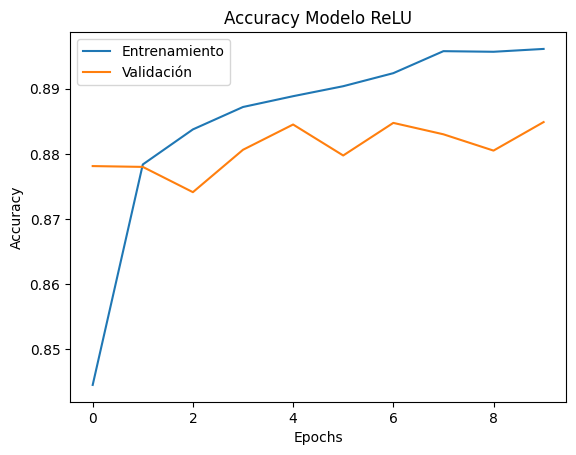

In [45]:
plt.plot(history_relu.history['accuracy'])
plt.plot(history_relu.history['val_accuracy'])
plt.title('Accuracy Modelo ReLU')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()

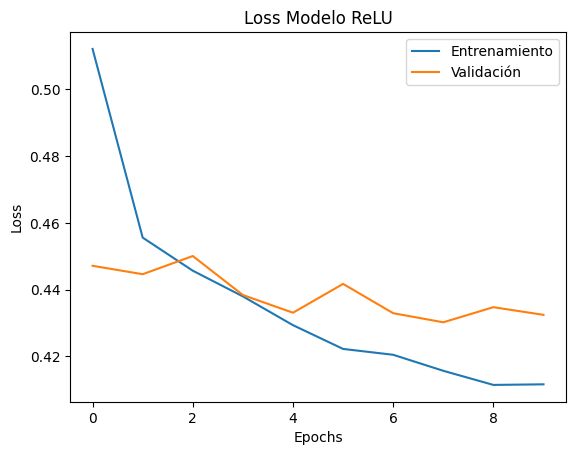

In [46]:
plt.plot(history_relu.history['loss'])
plt.plot(history_relu.history['val_loss'])
plt.title('Loss Modelo ReLU')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()

In [47]:
y_pred_relu_prob = modelo_relu.predict(X_test_vec)
y_pred_relu = (y_pred_relu_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [48]:
acc1 = accuracy_score(y_test, y_pred_relu)
prec1 = precision_score(y_test, y_pred_relu)
rec1 = recall_score(y_test, y_pred_relu)
f1_1 = f1_score(y_test, y_pred_relu)

print("Accuracy:", acc1)
print("Precision:", prec1)
print("Recall:", rec1)
print("F1-score:", f1_1)

Accuracy: 0.8852
Precision: 0.8815454010590312
Recall: 0.8920420718396507
F1-score: 0.886762675083843


In [49]:
print(classification_report(y_test, y_pred_relu))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4961
           1       0.88      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## Experimentos realizados

Se realizaron tres configuraciones distintas para comparar el rendimiento del modelo.

### Experimento 1: Modelo base
- Activación: ReLU
- Learning rate: 0.001

Este modelo sirve como referencia inicial.

### Experimento 2: Cambio de activación
- Activación: Tanh
- Learning rate: 0.001

Aquí se cambia solo la función de activación para observar cómo afecta el rendimiento.

### Experimento 3: Cambio de tasa de aprendizaje
- Activación: ReLU
- Learning rate: 0.0005

En este caso se reduce la velocidad de aprendizaje para evaluar si mejora la precisión.

In [50]:
modelo_tanh = crear_modelo_mlp(
    funcion_activacion='tanh',
    tasa_aprendizaje=0.001
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
history_tanh = modelo_tanh.fit(
    X_train_vec,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8559 - loss: 0.5017 - precision: 0.8483 - recall: 0.8659 - val_accuracy: 0.8742 - val_loss: 0.4479 - val_precision: 0.8988 - val_recall: 0.8435
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8818 - loss: 0.4311 - precision: 0.8774 - recall: 0.8870 - val_accuracy: 0.8795 - val_loss: 0.4236 - val_precision: 0.8828 - val_recall: 0.8752
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8859 - loss: 0.4174 - precision: 0.8817 - recall: 0.8907 - val_accuracy: 0.8717 - val_loss: 0.4354 - val_precision: 0.9126 - val_recall: 0.8223
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8875 - loss: 0.4085 - precision: 0.8848 - recall: 0.8904 - val_accuracy: 0.8817 - val_loss: 0.4084 - val_precision: 0.8769 - val_recall: 0.8882
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8896 - loss: 0.4019 - precision: 0.8852 - recall: 0.8946 - val_accuracy: 0

In [52]:
y_pred_tanh_prob = modelo_tanh.predict(X_test_vec)
y_pred_tanh = (y_pred_tanh_prob > 0.5).astype(int)

acc2 = accuracy_score(y_test, y_pred_tanh)
f1_2 = f1_score(y_test, y_pred_tanh)

print("Accuracy TANH:", acc2)
print("F1 TANH:", f1_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy TANH: 0.8877
F1 TANH: 0.8888008713734034


In [53]:
modelo_lr = crear_modelo_mlp(
    funcion_activacion='relu',
    tasa_aprendizaje=0.0005
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
history_lr = modelo_lr.fit(
    X_train_vec,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8370 - loss: 0.5060 - precision: 0.8384 - recall: 0.8340 - val_accuracy: 0.8824 - val_loss: 0.4057 - val_precision: 0.8974 - val_recall: 0.8635
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8904 - loss: 0.3984 - precision: 0.8871 - recall: 0.8939 - val_accuracy: 0.8815 - val_loss: 0.3981 - val_precision: 0.9014 - val_recall: 0.8568
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8973 - loss: 0.3842 - precision: 0.8944 - recall: 0.9006 - val_accuracy: 0.8836 - val_loss: 0.3956 - val_precision: 0.8611 - val_recall: 0.9147
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8984 - loss: 0.3732 - precision: 0.8938 - recall: 0.9036 - val_accuracy: 0.8851 - val_loss: 0.3909 - val_precision: 0.8856 - val_recall: 0.8845
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9027 - loss: 0.3654 - precision: 0.8999 - recall: 0.9058 - val_accuracy: 0

In [55]:
y_pred_lr_prob = modelo_lr.predict(X_test_vec)
y_pred_lr = (y_pred_lr_prob > 0.5).astype(int)

acc3 = accuracy_score(y_test, y_pred_lr)
f1_3 = f1_score(y_test, y_pred_lr)

print("Accuracy LR Bajo:", acc3)
print("F1 LR Bajo:", f1_3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy LR Bajo: 0.8837
F1 LR Bajo: 0.8887826336425361


In [56]:
resultados = pd.DataFrame({
    'Modelo': ['ReLU', 'Tanh', 'ReLU LR Bajo'],
    'Accuracy': [acc1, acc2, acc3],
    'F1-score': [f1_1, f1_2, f1_3]
})

print(resultados)

         Modelo  Accuracy  F1-score
0          ReLU    0.8852  0.886763
1          Tanh    0.8877  0.888801
2  ReLU LR Bajo    0.8837  0.888783


## Análisis del mejor modelo

Después de comparar los resultados, se identifica el modelo con mayor accuracy.

El mejor modelo es aquel que logra:
- Mayor precisión en clasificación.
- Mejor equilibrio entre accuracy y F1-score.

Esto permite concluir cuál configuración entrega mejores resultados para este problema.

In [57]:
mejor_modelo = resultados.loc[resultados['Accuracy'].idxmax()]
print("Mejor modelo:")
print(mejor_modelo)

Mejor modelo:
Modelo          Tanh
Accuracy      0.8877
F1-score    0.888801
Name: 1, dtype: object


In [58]:
print("Conclusión:")
print("El modelo con mejor accuracy fue:", mejor_modelo['Modelo'])

Conclusión:
El modelo con mejor accuracy fue: Tanh


## Conclusión general

En este proyecto se construyó una red neuronal MLP para clasificar reseñas de películas como positivas o negativas.

Se aplicó preprocesamiento de texto mediante TF-IDF, se entrenaron distintos modelos y se compararon sus resultados.

Los experimentos permitieron comprobar cómo pequeños cambios en hiperparámetros afectan el rendimiento del modelo.

Esto demuestra la importancia de ajustar correctamente la arquitectura y configuración de una red neuronal.